In [17]:
# Manejo de datos y utilidades
import pandas as pd
import numpy as np
from itertools import product
import warnings

# Modelo SARIMAX
import statsmodels.api as sm

# Métricas de Evaluación y Visualización
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Configuración de gráficos y advertencias
plt.rcParams['figure.figsize'] = (14, 7)
# Se ignoran las advertencias comunes de convergencia en el Grid Search
warnings.filterwarnings("ignore")

In [18]:
# --- 1. Funciones de utilidad ---

def agregar_lags(df, columna, lags):
    """Crea variables de retardo (lags)."""
    for lag in lags:
        df[f'lag_{lag}'] = df[columna].shift(lag)
    return df

def agregar_medias_moviles(df, columna, ventanas):
    """Crea variables de medias móviles (rolling means). Shift(1) evita data leakage."""
    for ventana in ventanas:
        df[f'media_movil_{ventana}'] = df[columna].rolling(window=ventana).mean().shift(1)
    return df

def agregar_ewma(df, columna, ventanas):
    """Crea variables EWMA (Exponential Weighted Moving Average). Shift(1) evita data leakage."""
    for ventana in ventanas:
        df[f'ewma_{ventana}'] = df[columna].ewm(span=ventana).mean().shift(1)
    return df

def agregar_variables_ciclicas(df, date_col):
    """Crea variables seno/coseno para Mes y Día de la Semana."""
    # Mes (Ciclo de 12)
    df['mes_sin'] = np.sin(2 * np.pi * df[date_col].dt.month / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df[date_col].dt.month / 12)
    # Día de la Semana (Ciclo de 7, 0=Lunes, 6=Sábado, ya eliminamos el Domingo)
    df['dia_semana_sin'] = np.sin(2 * np.pi * df[date_col].dt.weekday / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * df[date_col].dt.weekday / 7)
    return df

def obtener_semestre(mes):
    """Asigna el semestre basado en el mes (UDEC)."""
    return 1 if mes in range(3, 8) else 2 # Marzo-Julio (1), Agosto-Febrero (2)

def semana_en_semestre(row):
    """Calcula la semana del semestre. CORRECCIÓN: sin .dt en el objeto Timestamp."""
    # Accede directamente al método isocalendar() del objeto Timestamp para obtener la semana
    return row['Fecha'].isocalendar().week % 25

In [19]:
# --- 2. Preparación y División de Datos (Exógenas y Target) ---

try:
    # Intento de carga (Ajusta esta ruta a tu proyecto)
    daily_counts_full = pd.read_csv("Datasets/daily_counts_full.csv")
    print("Dataset cargado desde 'Datasets/daily_counts_full.csv'")
except FileNotFoundError:
    print("ERROR: No se encontró el archivo 'daily_counts_full.csv'.")
    # Creación de DataFrame dummy para simular datos y continuar
    print("Creando DataFrame dummy para simular datos y continuar con el código.")
    np.random.seed(42)
    dates = pd.date_range('2022-01-01', periods=500, freq='D')
    daily_counts_full = pd.DataFrame({
        'Fecha': dates,
        'Accesos': np.random.randint(500, 5000, size=500),
        'Vacaciones': np.where((dates.month.isin([1, 7, 12])) | (dates.day_of_week.isin([5])), 1, 0)
    })
    daily_counts_full['Mes'] = daily_counts_full['Fecha'].dt.month
    daily_counts_full['Semestre'] = 0 
    daily_counts_full['Semana_Certamen'] = 0 


# A. Feature Engineering (Aplicando el pipeline completo)
for col in ['Accesos']:
    daily_counts_full[col] = daily_counts_full[col].fillna(0).astype(int) 

daily_counts_full['Fecha'] = pd.to_datetime(daily_counts_full['Fecha'])
# Eliminación de Domingo (día 6)
daily_counts_full = daily_counts_full[
    daily_counts_full['Fecha'].dt.weekday != 6 
].reset_index(drop=True)

daily_counts_full['Mes'] = daily_counts_full['Fecha'].dt.month

# Aplicación de todas las funciones de Features
daily_counts_full = agregar_medias_moviles(daily_counts_full, 'Accesos', [7, 14, 30])
daily_counts_full = agregar_variables_ciclicas(daily_counts_full, 'Fecha')
daily_counts_full = agregar_ewma(daily_counts_full, 'Accesos', [7, 14, 30])
daily_counts_full['Semestre'] = daily_counts_full['Mes'].apply(obtener_semestre)
daily_counts_full['Semana_Semestre'] = daily_counts_full.apply(semana_en_semestre, axis=1)
daily_counts_full['Semana_Certamen'] = daily_counts_full['Semana_Semestre'].isin([6, 7]).astype(int)
daily_counts_full = agregar_lags(daily_counts_full, 'Accesos', [7, 14, 21])


# B. Definición y Split
# El .dropna() elimina las primeras filas donde los lags y medias móviles son NaN
data_sarimax = daily_counts_full.set_index('Fecha').dropna() 

# Conjunto completo de features (exógenas para SARIMAX)
FEATURES = ['Vacaciones', 'Semana_Certamen', 'media_movil_7', 'media_movil_14', 'media_movil_30',
            'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos',
            'lag_7', 'lag_14', 'lag_21', 'ewma_7', 'ewma_14', 'ewma_30']
TARGET = 'Accesos'

X_sarimax = data_sarimax[FEATURES]
y_sarimax = data_sarimax[TARGET]

# Split temporal 80/20
split_ratio = 0.8
split_point = int(len(data_sarimax) * split_ratio)

y_train = y_sarimax.iloc[:split_point]
y_test = y_sarimax.iloc[split_point:]
X_train = X_sarimax.iloc[:split_point]
X_test = X_sarimax.iloc[split_point:]

print(f"\n--- Preparación de Datos Finalizada ---")
print(f"SARIMAX: Datos de entrenamiento: {len(y_train)} | Datos de prueba: {len(y_test)}")
print(f"Número de Features Exógenas: {len(FEATURES)}")

Dataset cargado desde 'Datasets/daily_counts_full.csv'

--- Preparación de Datos Finalizada ---
SARIMAX: Datos de entrenamiento: 326 | Datos de prueba: 82
Número de Features Exógenas: 15


In [24]:
# --- 3. Grid Search para la Optimización de Órdenes (p, d, q) x (P, D, Q, s) ---

from itertools import product
import statsmodels.api as sm
import numpy as np

# --- Definición del espacio de búsqueda ---
p = d = q = range(0, 2)            
seasonal_p = seasonal_d = seasonal_q = range(0, 2)
s = 7                              # Período estacional (semanal)

pdq = list(product(p, d, q))
seasonal_pdq = list(product(seasonal_p, seasonal_d, seasonal_q, [s]))

best_aic = np.inf
best_order = None
best_seasonal_order = None

print("\nIniciando Grid Search para encontrar órdenes óptimas...")

# Bucle para probar todas las combinaciones
for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            model_sarimax = sm.tsa.SARIMAX(
                y_train,
                exog=X_train, 
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False 
            )
            # El fit se realiza sin mostrar la salida (disp=False)
            results = model_sarimax.fit(disp=False)
            
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_seasonal_order = seasonal_order
                
        except:
            continue

print("\n--- Grid Search Finalizado ---")
print(f"Mejor AIC: {best_aic:.2f}")
print(f"Mejor Orden No Estacional (p, d, q): {best_order}")
print(f"Mejor Orden Estacional (P, D, Q, s): {best_seasonal_order}")


Iniciando Grid Search para encontrar órdenes óptimas...

--- Grid Search Finalizado ---
Mejor AIC: 5111.87
Mejor Orden No Estacional (p, d, q): (0, 0, 1)
Mejor Orden Estacional (P, D, Q, s): (1, 1, 1, 7)



  RESUMEN ESTADÍSTICO DEL SARIMAX
                                     SARIMAX Results                                     
Dep. Variable:                           Accesos   No. Observations:                  326
Model:             SARIMAX(0, 0, 1)x(1, 1, 1, 7)   Log Likelihood               -2536.934
Date:                           Sun, 30 Nov 2025   AIC                           5111.867
Time:                                   17:22:29   BIC                           5182.862
Sample:                                        0   HQIC                          5140.248
                                           - 326                                         
Covariance Type:                             opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Vacaciones       -837.7789    247.124     -3.390      0.001   -1322.134    -3

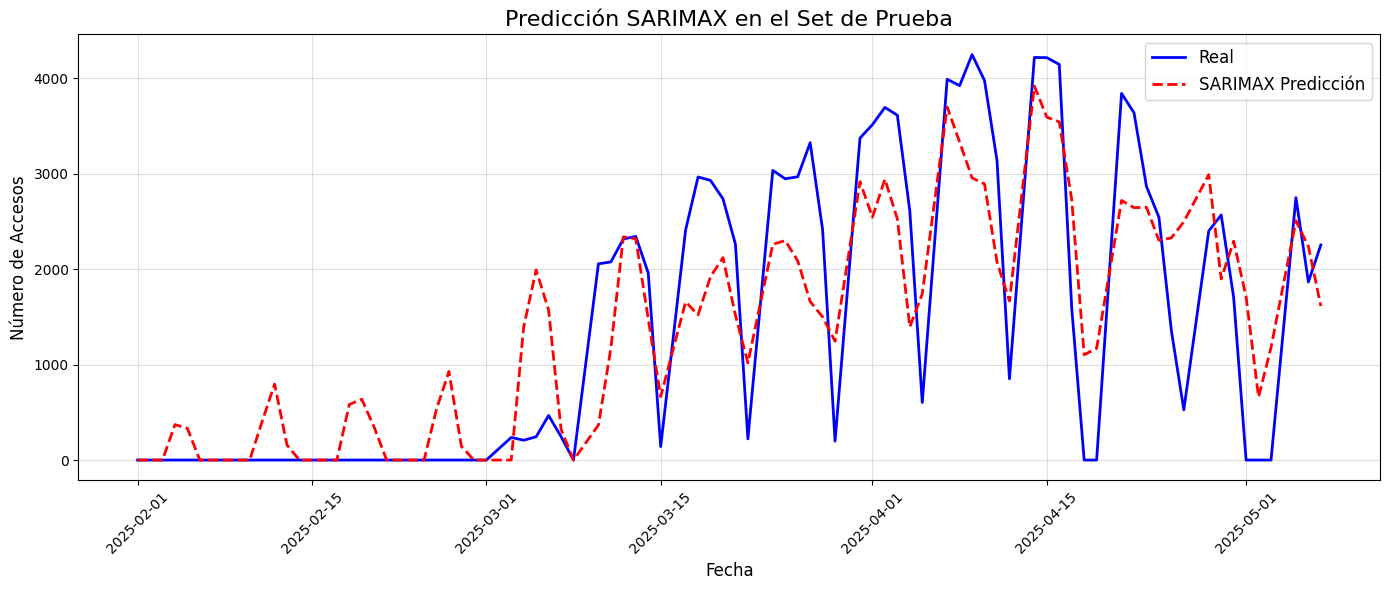

In [30]:
# --- 4. Entrenamiento del Modelo Final y 5. Evaluación de Métricas ---

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Se asume que best_order y best_seasonal_order fueron definidos en el Grid Search
FINAL_ORDER = best_order
FINAL_SEASONAL_ORDER = best_seasonal_order

# --- Entrenamiento Final ---
final_sarimax = sm.tsa.SARIMAX(
    y_train,
    exog=X_train, 
    order=FINAL_ORDER,
    seasonal_order=FINAL_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_sarimax.fit(disp=False)

# --- Resumen Estadístico (P-valores de Significación) ---
print("\n==================================")
print("  RESUMEN ESTADÍSTICO DEL SARIMAX")
print("==================================")
print(final_results.summary()) 


# --- Predicción y Cálculo de Métricas (SOLUCIÓN A LA ALINEACIÓN DE ÍNDICES) ---
forecast_steps = len(y_test)
# La predicción utiliza X_test como variables exógenas
prediction = final_results.get_forecast(steps=forecast_steps, exog=X_test) 
pred_mean = prediction.predicted_mean

# 🛠️ CORRECCIÓN CRÍTICA: Asignar el índice de y_test a la predicción
pred_mean.index = y_test.index

# Limpiar valores (no puede haber accesos negativos)
pred_mean[pred_mean < 0] = 0

# CÁLCULO DE MÉTRICAS: Usamos .values para asegurar la comparación de arrays numéricos de 82 puntos
rmse = np.sqrt(mean_squared_error(y_test.values, pred_mean.values))
mae = mean_absolute_error(y_test.values, pred_mean.values)
r2 = r2_score(y_test.values, pred_mean.values)

# Cálculo de MAPE
mape = np.mean(np.abs((y_test.values - pred_mean.values) / y_test.values.clip(min=np.finfo(float).eps))) * 100


# --- Resultados de Evaluación ---
print("\n==================================")
print("  MÉTRICAS DE EVALUACIÓN FINAL")
print("==================================")
print(f"RMSE (Accesos): {rmse:.2f}")
print(f"MAE (Accesos): {mae:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAPE (%): {mape:.2f}%")


# Creación del DataFrame de Resultados (Ahora que los índices coinciden)
results_df = pd.DataFrame({'Real': y_test, 'Predicción': pred_mean})
results_df = results_df.dropna() # Esto solo eliminará NaNs si pred_mean tuviera alguno


# --- 6. Visualización de Resultados (Gráfico Funcional) ---

if results_df.empty:
    print("ERROR DE VISUALIZACIÓN: El DataFrame 'results_df' sigue vacío.")
else:
    plt.figure(figsize=(14, 6))
    
    # Usamos el índice de resultados_df (que es la Fecha) como eje X
    plt.plot(results_df.index, results_df['Real'], label='Real', color='blue', linewidth=2)
    plt.plot(results_df.index, results_df['Predicción'], label='SARIMAX Predicción', color='red', linestyle='--', linewidth=2)
    
    plt.title('Predicción SARIMAX en el Set de Prueba', fontsize=16)
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Número de Accesos', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

--- 7. Pronóstico a Futuro (Corrección de 15 variables) ---
Generando predicción para: 2025-05-08 al 2025-05-15 (7 días)

--- Pronóstico Exitoso ---
            Prediccion
2025-05-08        2558
2025-05-09        2788
2025-05-10        2210
2025-05-12        3219
2025-05-13        2909
2025-05-14        3588
2025-05-15        3148


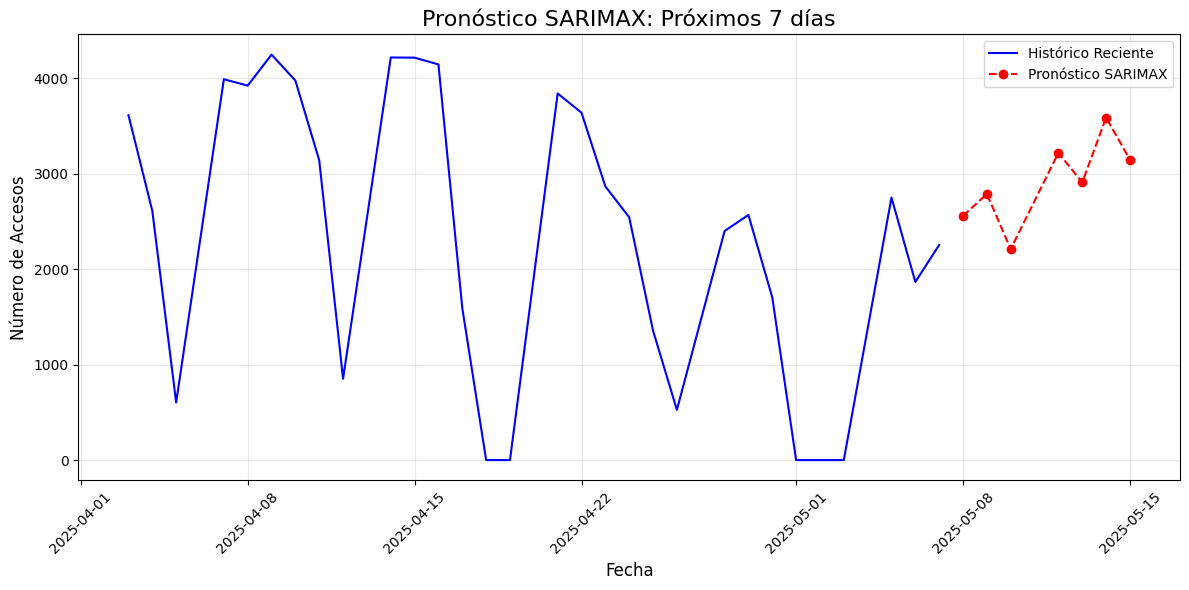

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- 7. Pronóstico a Futuro (Corrección de 15 variables) ---")

# 1. Configuración
DAYS_TO_PREDICT = 7
last_date = daily_counts_full['Fecha'].max()
future_dates_full = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=DAYS_TO_PREDICT * 2, freq='D') # Damos margen

# Eliminamos el domingo (día 6) de las fechas futuras, tal como hicimos en la preparación
future_dates = future_dates_full[future_dates_full.dayofweek != 6][:DAYS_TO_PREDICT]
DAYS_TO_PREDICT = len(future_dates)


# Copia de seguridad para ir agregando predicciones (Fecha como índice)
current_data = daily_counts_full.copy().set_index('Fecha')
future_predictions = []

print(f"Generando predicción para: {future_dates[0].date()} al {future_dates[-1].date()} ({DAYS_TO_PREDICT} días)")

# 2. Bucle Recursivo (Walk-Forward)
for date in future_dates:
    # --- A. Calcular Fechas y Eventos ---
    mes = date.month
    weekday = date.weekday()
    
    # 1. Cíclicas (4 vars)
    mes_sin = np.sin(2 * np.pi * mes / 12)
    mes_cos = np.cos(2 * np.pi * mes / 12)
    dia_sin = np.sin(2 * np.pi * weekday / 7)
    dia_cos = np.cos(2 * np.pi * weekday / 7)
    
    # 2. Variables Académicas y de Eventos (CORREGIDO)
    es_vacaciones = 0 # Asumimos 0 por defecto (AJUSTAR MANUALMENTE si cae en vacaciones)
    
    # Cálculo de Semana_Certamen (Replica la lógica de las funciones en tu Feature Engineering)
    # Se obtiene la semana del semestre y se verifica si es la 6 o 7
    semana_semestre_val = date.isocalendar().week % 25
    es_semana_certamen = 1 if semana_semestre_val in [6, 7] else 0

    
    # --- B. Calcular Variables dependientes del pasado (9 vars) ---
    historia = current_data['Accesos']
    
    # Medias Móviles (últimos X días predichos/reales)
    mm_7 = historia.iloc[-7:].mean()
    mm_14 = historia.iloc[-14:].mean()
    mm_30 = historia.iloc[-30:].mean()
    
    # Lags (Valores pasados exactos)
    lag_7 = historia.iloc[-7]
    lag_14 = historia.iloc[-14]
    lag_21 = historia.iloc[-21]
    
    # EWMA (Media móvil exponencial)
    ewma_7 = historia.ewm(span=7, adjust=False).mean().iloc[-1]
    ewma_14 = historia.ewm(span=14, adjust=False).mean().iloc[-1]
    ewma_30 = historia.ewm(span=30, adjust=False).mean().iloc[-1]

    # --- C. Crear DataFrame con las 15 FEATURES exactas (Mismo orden que la lista FEATURES) ---
    exog_future = pd.DataFrame({
        'Vacaciones': [es_vacaciones],
        'Semana_Certamen': [es_semana_certamen],
        'media_movil_7': [mm_7],
        'media_movil_14': [mm_14],
        'media_movil_30': [mm_30],
        'mes_sin': [mes_sin],
        'mes_cos': [mes_cos],
        'dia_semana_sin': [dia_sin],
        'dia_semana_cos': [dia_cos],
        'lag_7': [lag_7],
        'lag_14': [lag_14],
        'lag_21': [lag_21],
        'ewma_7': [ewma_7],
        'ewma_14': [ewma_14],
        'ewma_30': [ewma_30]
    }, index=[date])

    # --- D. Predecir ---
    forecast = final_results.get_forecast(steps=1, exog=exog_future)
    pred_value = np.maximum(forecast.predicted_mean.iloc[0], 0)
    
    # --- E. Actualizar para el siguiente ciclo ---
    future_predictions.append(pred_value)
    
    # Agregamos la predicción como si fuera un dato real para los cálculos de mañana
    current_data.loc[date, 'Accesos'] = pred_value


# 3. Resultado Final
df_forecast = pd.DataFrame({
    'Prediccion': np.round(future_predictions).astype(int)
}, index=future_dates)

print("\n--- Pronóstico Exitoso ---")
print(df_forecast)

# --- 4. Visualización del Pronóstico ---
plt.figure(figsize=(12, 6))

# Datos históricos recientes (últimos 30 días)
# Se usa iloc para tomar los 30 días de historia antes del pronóstico.
hist_slice = current_data['Accesos'].iloc[-DAYS_TO_PREDICT-30:-DAYS_TO_PREDICT] 
plt.plot(hist_slice.index, hist_slice.values, label='Histórico Reciente', color='blue')

# Predicción
plt.plot(df_forecast.index, df_forecast['Prediccion'], 
         label='Pronóstico SARIMAX', 
         linestyle='--', marker='o', color='red')

plt.title(f'Pronóstico SARIMAX: Próximos {DAYS_TO_PREDICT} días', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Accesos', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()